# Method E — Master Comparison: All 5 SCM Estimators
## Base SCM · ASCM · EN-SCM · MC-SCM · SDID

**Purpose:**  
Re-runs every estimator from scratch in a single execution context, then produces a unified  
comparison across all five methods. Run this after validating each individual notebook.

| # | Method | Core innovation |
|---|--------|----------------|
| 0 | **Base SCM** | Constrained weights, 5-donor convex combination |
| 1 | **ASCM** | Ridge bias-correction on SCM residuals |
| 2 | **EN-SCM** | Elastic net (L1+L2) regularised weights |
| 3 | **MC-SCM** | Nuclear norm matrix completion (no donor weights) |
| 4 | **SDID** | Unit weights + time weights + jackknife SE |

**Output:** unified metrics table, overlaid counterfactual plot, ratio bar chart,  
cumulative effect comparison, method agreement heatmap, and final verdict.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Imports & Plotting Config
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from sklearn.linear_model import Ridge
import itertools
import os
import warnings
warnings.filterwarnings('ignore')

FIG_DIR = '../method_A_graph'
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--', 'font.size': 10,
})

METHOD_COLORS = {
    'Base SCM': '#aaaaaa',
    'ASCM':     '#e94560',
    'EN-SCM':   '#f39c12',
    'MC-SCM':   '#2ecc71',
    'SDID':     '#0f3460',
}
METHOD_LS = {
    'Base SCM': ':',
    'ASCM':     '--',
    'EN-SCM':   '-.',
    'MC-SCM':   (0, (3, 1, 1, 1)),
    'SDID':     '-',
}

print("Master comparison notebook ready.")
print(f"Methods: {list(METHOD_COLORS.keys())}")
print(f"Figures will save to: {os.path.abspath(FIG_DIR)}")

Master comparison notebook ready.
Methods: ['Base SCM', 'ASCM', 'EN-SCM', 'MC-SCM', 'SDID']
Figures will save to: /Users/sitta/Desktop/coding/thesis/method_A_graph


**What is happening here**  
All required libraries are imported and a consistent colour and line-style scheme is defined for each method. Every subsequent plot uses these colours so results from the same method are immediately identifiable across all figures.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Data Loading (shared across all methods)
# ═══════════════════════════════════════════════════════════════════════════════

CSV_PATH = './data/corridor_panel_clean.csv'

df = pd.read_csv(CSV_PATH)
df['Date']        = pd.to_datetime(df['Date'])
df['Corridor']    = df['Corridor'].astype(str).str.strip()
df['Date_period'] = pd.PeriodIndex(df['Date'].dt.to_period('M'))

Y_COL       = 'Rail_Vol_mt'
TREATED     = 'NATCOR'
TREAT_START = pd.Period('2022-04', freq='M')
PRE_END     = TREAT_START - 1

wide     = df.pivot(index='Date_period', columns='Corridor', values=Y_COL).sort_index()
donors   = [c for c in wide.columns if c != TREATED]
pre_idx  = wide.index[wide.index <= PRE_END]
post_idx = wide.index[wide.index >= TREAT_START]
T_pre    = len(pre_idx)
T_post   = len(post_idx)
T_total  = len(wide)
t_stamps = wide.index.to_timestamp()
treat_t  = TREAT_START.to_timestamp()
nat_col  = list(wide.columns).index(TREATED)

Y_all    = wide[TREATED].values
X_all    = wide[donors].values
Y_pre_v  = wide.loc[pre_idx,  TREATED].values
Y_post_v = wide.loc[post_idx, TREATED].values
X_pre_v  = wide.loc[pre_idx,  donors].values
X_post_v = wide.loc[post_idx, donors].values
Y_mat    = wide.values.astype(float)

def rmspe(a, b): return np.sqrt(np.mean((np.asarray(a) - np.asarray(b))**2))
def mape(a, b):
    a = np.asarray(a)
    return np.mean(np.abs((a - b) / np.where(a == 0, 1e-10, a))) * 100

print(f"Data loaded: {T_total} periods  |  {T_pre} pre  |  {T_post} post")
print(f"Corridors : {list(wide.columns)}")
print(f"Donors    : {donors}")

Data loaded: 120 periods  |  87 pre  |  33 post
Corridors : ['CAPE', 'IRON_ORE', 'NATCOR', 'NE_CORRIDOR', 'NORTHCOR', 'SOUTHCOR']
Donors    : ['CAPE', 'IRON_ORE', 'NE_CORRIDOR', 'NORTHCOR', 'SOUTHCOR']


**What is happening here**  
The cleaned panel is loaded once and shared across all five methods. All arrays are defined here so no method re-reads the file.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Method 0: Base SCM
# ═══════════════════════════════════════════════════════════════════════════════

def fit_scm(Y_pre, X_pre):
    if X_pre.ndim == 1: X_pre = X_pre.reshape(-1, 1)
    n = X_pre.shape[1]
    res = minimize(lambda w: np.sum((Y_pre - X_pre @ w)**2),
                   np.ones(n)/n, method='SLSQP',
                   bounds=[(0,1)]*n,
                   constraints={'type':'eq','fun': lambda w: w.sum()-1},
                   options={'ftol':1e-12,'maxiter':5000})
    return np.clip(res.x, 0, None)

w_scm   = fit_scm(Y_pre_v, X_pre_v)
cf_scm  = X_all @ w_scm
gap_scm = Y_all - cf_scm

results = {}
results['Base SCM'] = {
    'cf': cf_scm, 'gap': gap_scm,
    'pre_r':  rmspe(Y_all[:T_pre], cf_scm[:T_pre]),
    'post_r': rmspe(Y_all[T_pre:], cf_scm[T_pre:]),
    'cum':    gap_scm[T_pre:].sum(),
    'avg':    gap_scm[T_pre:].mean(),
    'mape':   mape(Y_all[T_pre:], cf_scm[T_pre:]),
    'notes':  f'weights={dict(zip(donors,w_scm.round(3)))}',
}
r = results['Base SCM']
print(f"Base SCM  — Pre:{r['pre_r']:.4f} Post:{r['post_r']:.4f} "
      f"Ratio:{r['post_r']/r['pre_r']:.4f} Cum:{r['cum']:.4f}")

Base SCM  — Pre:0.0261 Post:0.1704 Ratio:6.5350 Cum:-5.2075


**What is happening here**  
The standard constrained SCM is run as the baseline. All results are stored in the `results` dictionary under the key `'Base SCM'` for easy comparison later.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Method 1: ASCM
# ═══════════════════════════════════════════════════════════════════════════════

def make_ridge_features(X_donors, t_idx, T_pre):
    t_norm = (t_idx / T_pre).reshape(-1, 1)
    blocks = []
    for j in range(X_donors.shape[1]):
        d = X_donors[:, j].reshape(-1, 1)
        blocks.append(np.hstack([d, t_norm, t_norm**2, d * t_norm]))
    return np.hstack(blocks)

t_pre_idx = np.arange(T_pre)
t_all_idx = np.arange(T_total)
feat_pre  = make_ridge_features(X_pre_v, t_pre_idx, T_pre)
feat_all  = make_ridge_features(X_all,   t_all_idx, T_pre)
res_pre   = Y_pre_v - cf_scm[:T_pre]

split = int(0.6 * T_pre)
ALPHA_GRID = [1e-5,5e-5,1e-4,5e-4,1e-3,5e-3,0.01,0.05,0.1,0.5,1.0,5.0,10.0,50.0,100.0]
best_a, best_e = None, np.inf
for a in ALPHA_GRID:
    m = Ridge(alpha=a, fit_intercept=True).fit(feat_pre[:split], res_pre[:split])
    e = rmspe(res_pre[split:], m.predict(feat_pre[split:]))
    if e < best_e: best_e, best_a = e, a

ridge_f    = Ridge(alpha=best_a, fit_intercept=True).fit(feat_pre, res_pre)
correction = ridge_f.predict(feat_all)
cf_ascm    = cf_scm + correction
gap_ascm   = Y_all - cf_ascm

results['ASCM'] = {
    'cf': cf_ascm, 'gap': gap_ascm,
    'pre_r':  rmspe(Y_all[:T_pre], cf_ascm[:T_pre]),
    'post_r': rmspe(Y_all[T_pre:], cf_ascm[T_pre:]),
    'cum':    gap_ascm[T_pre:].sum(),
    'avg':    gap_ascm[T_pre:].mean(),
    'mape':   mape(Y_all[T_pre:], cf_ascm[T_pre:]),
    'notes':  f'α={best_a}',
}
r = results['ASCM']
print(f"ASCM      — Pre:{r['pre_r']:.4f} Post:{r['post_r']:.4f} "
      f"Ratio:{r['post_r']/r['pre_r']:.4f} Cum:{r['cum']:.4f}  (α={best_a})")

ASCM      — Pre:0.0260 Post:0.1679 Ratio:6.4504 Cum:-5.1109  (α=100.0)


**What is happening here**  
ASCM is re-run: blocked CV selects the ridge alpha, then the correction is applied to the base SCM counterfactual. The n-donor version of `make_ridge_features` is used, building feature blocks for all 5 donors.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Method 2: EN-SCM
# ═══════════════════════════════════════════════════════════════════════════════

def fit_elastic_scm(Y_pre, X_pre, alpha=0.01, l1_ratio=0.5):
    if X_pre.ndim == 1: X_pre = X_pre.reshape(-1, 1)
    n = X_pre.shape[1]
    def loss(w):
        r = Y_pre - X_pre @ w
        return np.mean(r**2) + alpha*l1_ratio*np.sum(np.abs(w)) + alpha*(1-l1_ratio)*0.5*np.sum(w**2)
    res = minimize(loss, np.ones(n)/n, method='SLSQP',
                   bounds=[(0,None)]*n, options={'ftol':1e-14,'maxiter':10000})
    return np.clip(res.x, 0, None)

alpha_g   = [1e-4,5e-4,1e-3,5e-3,0.01,0.05,0.1,0.5,1.0]
l1ratio_g = [0.0,0.1,0.25,0.5,0.75,0.9,1.0]
sp_en     = int(0.6 * T_pre)
best_a2, best_l2, best_e2 = None, None, np.inf
for a, l in itertools.product(alpha_g, l1ratio_g):
    w = fit_elastic_scm(Y_pre_v[:sp_en], X_pre_v[:sp_en], alpha=a, l1_ratio=l)
    e = rmspe(Y_pre_v[sp_en:], X_pre_v[sp_en:] @ w)
    if e < best_e2: best_e2, best_a2, best_l2 = e, a, l

w_en   = fit_elastic_scm(Y_pre_v, X_pre_v, alpha=best_a2, l1_ratio=best_l2)
cf_en  = X_all @ w_en
gap_en = Y_all - cf_en

results['EN-SCM'] = {
    'cf': cf_en, 'gap': gap_en,
    'pre_r':  rmspe(Y_all[:T_pre], cf_en[:T_pre]),
    'post_r': rmspe(Y_all[T_pre:], cf_en[T_pre:]),
    'cum':    gap_en[T_pre:].sum(),
    'avg':    gap_en[T_pre:].mean(),
    'mape':   mape(Y_all[T_pre:], cf_en[T_pre:]),
    'notes':  f'α={best_a2},L1={best_l2}',
}
r = results['EN-SCM']
print(f"EN-SCM    — Pre:{r['pre_r']:.4f} Post:{r['post_r']:.4f} "
      f"Ratio:{r['post_r']/r['pre_r']:.4f} Cum:{r['cum']:.4f}  (α={best_a2},L1={best_l2})")

EN-SCM    — Pre:0.0268 Post:0.1697 Ratio:6.3267 Cum:-5.1950  (α=0.0005,L1=0.25)


**What is happening here**  
EN-SCM is re-run with a 2-D blocked CV over the full 63-combination grid. The n-donor matrix is passed directly to the solver.

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Method 3: MC-SCM
# ═══════════════════════════════════════════════════════════════════════════════

def svt(Y_obs, mask, lam, max_iter=2000, tol=1e-7):
    M = np.where(mask, Y_obs, 0.0)
    for _ in range(max_iter):
        U, s, Vt = np.linalg.svd(M, full_matrices=False)
        s_t = np.maximum(s - lam, 0)
        M_new = (U * s_t) @ Vt
        M_new = np.where(mask, Y_obs, M_new)
        change = np.linalg.norm(M_new - M, 'fro') / (np.linalg.norm(M, 'fro') + 1e-12)
        M = M_new
        if change < tol: break
    return M, s_t, int(np.sum(s_t > 0))

mask_full = np.ones(Y_mat.shape, dtype=bool)
mask_full[T_pre:, nat_col] = False

val_w = 25; train_end = T_pre - val_w
mask_cv = mask_full.copy(); mask_cv[train_end:T_pre, nat_col] = False
lam_grid = [0.001,0.003,0.005,0.008,0.01,0.015,0.02,0.03,0.05,0.075,0.1,0.15,0.2]
best_lam, best_el = None, np.inf
for lam in lam_grid:
    M_cv, _, _ = svt(Y_mat, mask_cv, lam=lam)
    e = rmspe(Y_mat[train_end:T_pre, nat_col], M_cv[train_end:T_pre, nat_col])
    if e < best_el: best_el, best_lam = e, lam

M_mc, _, rank_mc = svt(Y_mat, mask_full, lam=best_lam)
cf_mc   = M_mc[:, nat_col]
gap_mc  = Y_all - cf_mc

results['MC-SCM'] = {
    'cf': cf_mc, 'gap': gap_mc,
    'pre_r':  rmspe(Y_all[:T_pre], cf_mc[:T_pre]),
    'post_r': rmspe(Y_all[T_pre:], cf_mc[T_pre:]),
    'cum':    gap_mc[T_pre:].sum(),
    'avg':    gap_mc[T_pre:].mean(),
    'mape':   mape(Y_all[T_pre:], cf_mc[T_pre:]),
    'notes':  f'λ={best_lam},rank={rank_mc}',
}
r = results['MC-SCM']
print(f"MC-SCM    — Pre:{r['pre_r']:.4f} Post:{r['post_r']:.4f} "
      f"Ratio:{r['post_r']/r['pre_r']:.4f} Cum:{r['cum']:.4f}  (λ={best_lam},rank={rank_mc})")

MC-SCM    — Pre:0.0000 Post:0.1667 Ratio:inf Cum:-5.0834  (λ=0.2,rank=4)


**What is happening here**  
MC-SCM is re-run. The 6-corridor matrix is now the input, giving the SVT algorithm richer cross-sectional structure to work with compared with the old 2-corridor version.

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Method 4: SDID
# ═══════════════════════════════════════════════════════════════════════════════

def fit_unit_weights(Y_nat, X_don, lam_u=0.0):
    if X_don.ndim == 1: X_don = X_don.reshape(-1, 1)
    n = X_don.shape[1]
    def loss(w): return np.mean((Y_nat - X_don @ w)**2) + lam_u*np.sum(w**2)
    res = minimize(loss, np.ones(n)/n, method='SLSQP',
                   bounds=[(0,1)]*n,
                   constraints={'type':'eq','fun': lambda w: w.sum()-1},
                   options={'ftol':1e-14,'maxiter':10000})
    return np.clip(res.x, 0, None)

def fit_time_weights(X_pre, X_post, lam_t=1e-6):
    post_m = X_post.mean(axis=1).mean() if X_post.ndim > 1 else X_post.mean()
    pre_avg = X_pre.mean(axis=1) if X_pre.ndim > 1 else X_pre
    T = len(pre_avg)
    def loss(w): return (pre_avg @ w - post_m)**2 + lam_t*np.sum(w**2)
    res = minimize(loss, np.ones(T)/T, method='SLSQP',
                   bounds=[(0,None)]*T,
                   constraints={'type':'eq','fun': lambda w: w.sum()-1},
                   options={'ftol':1e-14,'maxiter':10000})
    return np.clip(res.x, 0, None)

LAM_TIME = 1e-6
lam_unit = fit_unit_weights(Y_pre_v, X_pre_v)
omega    = fit_time_weights(X_pre_v, X_post_v, lam_t=LAM_TIME)

nat_pre_wt    = omega @ Y_pre_v
donor_pre_wt  = X_pre_v.T @ omega
tau_sdid      = (Y_post_v.mean() - nat_pre_wt) - lam_unit @ (X_post_v.mean(axis=0) - donor_pre_wt)
level_adj     = nat_pre_wt - lam_unit @ donor_pre_wt
cf_sdid       = X_all @ lam_unit + level_adj
gap_sdid      = Y_all - cf_sdid

# Jackknife SE
pre_years = sorted(set(pre_idx.year))
jk_atts   = []
for yr in pre_years:
    keep = np.array([p.year != yr for p in pre_idx])
    if keep.sum() < 20: continue
    Y_jk = Y_pre_v[keep]; X_jk = X_pre_v[keep, :]
    om_jk = fit_time_weights(X_jk, X_post_v, lam_t=LAM_TIME)
    lm_jk = fit_unit_weights(Y_jk, X_jk)
    jk_atts.append(
        (Y_post_v.mean() - om_jk @ Y_jk) - lm_jk @ (X_post_v.mean(axis=0) - X_jk.T @ om_jk)
    )
n_jk   = len(jk_atts)
jk_var = ((n_jk-1)/n_jk) * np.sum((np.array(jk_atts) - np.mean(jk_atts))**2)
jk_se  = np.sqrt(jk_var)
t_stat = tau_sdid / jk_se if jk_se > 0 else np.nan

results['SDID'] = {
    'cf': cf_sdid, 'gap': gap_sdid,
    'pre_r':  rmspe(Y_all[:T_pre], cf_sdid[:T_pre]),
    'post_r': rmspe(Y_all[T_pre:], cf_sdid[T_pre:]),
    'cum':    gap_sdid[T_pre:].sum(),
    'avg':    gap_sdid[T_pre:].mean(),
    'mape':   mape(Y_all[T_pre:], cf_sdid[T_pre:]),
    'notes':  f'ATT={tau_sdid:.4f},SE={jk_se:.4f},t={t_stat:.2f}',
    'jk_se':  jk_se, 't_stat': t_stat,
    'ci_lo':  tau_sdid - 1.96*jk_se,
    'ci_hi':  tau_sdid + 1.96*jk_se,
}
r = results['SDID']
print(f"SDID      — Pre:{r['pre_r']:.4f} Post:{r['post_r']:.4f} "
      f"Ratio:{r['post_r']/r['pre_r']:.4f} Cum:{r['cum']:.4f}  (t={t_stat:.2f} SE={jk_se:.4f})")

SDID      — Pre:0.0261 Post:0.1712 Ratio:6.5629 Cum:-5.2366  (t=-65.61 SE=0.0024)


**What is happening here**  
SDID is re-run with n-donor unit weights and time weights. The jackknife SE is recomputed, giving the only formal t-statistic and confidence interval across all five methods.

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Unified Metrics Table
# ═══════════════════════════════════════════════════════════════════════════════

method_order = ['Base SCM', 'ASCM', 'EN-SCM', 'MC-SCM', 'SDID']
rows = []
for m in method_order:
    r     = results[m]
    ratio = r['post_r'] / r['pre_r']
    ci_str = 'N/A'
    if m == 'SDID':
        ci_str = f"[{r['ci_lo']*T_post:.2f}, {r['ci_hi']*T_post:.2f}]"
    rows.append({
        'Method':          m,
        'Pre-RMSPE':       round(r['pre_r'],  4),
        'Post-RMSPE':      round(r['post_r'], 4),
        'Ratio':           round(ratio, 4),
        'Ratio>1':         ratio > 1,
        'Cum Effect (MT)': round(r['cum'],    4),
        'Avg/ATT (MT/mo)': round(r['avg'],    4),
        'Post MAPE (%)':   round(r['mape'],   2),
        '95% CI cum':      ci_str,
        'Notes':           r['notes'],
    })

tbl = pd.DataFrame(rows)
print("═" * 100)
print("UNIFIED COMPARISON — ALL 5 ESTIMATORS")
print("═" * 100)
print(tbl.to_string(index=False))
print("═" * 100)
print()

cums = [results[m]['cum'] for m in method_order]
signs = [np.sign(c) for c in cums]
n_neg = sum(1 for s in signs if s < 0)
print(f"Direction agreement: {n_neg}/{len(method_order)} methods show a negative flood effect")
print(f"Cumulative effect range: [{min(cums):.4f}, {max(cums):.4f}] MT")
print(f"Spread across methods : {max(cums)-min(cums):.4f} MT")
n_above1 = sum(1 for m in method_order if results[m]['post_r']/results[m]['pre_r'] > 1)
print(f"Methods with Ratio > 1: {n_above1}/{len(method_order)}")

════════════════════════════════════════════════════════════════════════════════════════════════════
UNIFIED COMPARISON — ALL 5 ESTIMATORS
════════════════════════════════════════════════════════════════════════════════════════════════════
  Method  Pre-RMSPE  Post-RMSPE  Ratio  Ratio>1  Cum Effect (MT)  Avg/ATT (MT/mo)  Post MAPE (%)     95% CI cum                                                                                                                                                            Notes
Base SCM     0.0261      0.1704 6.5350     True          -5.2075          -0.1578          21.99            N/A weights={'CAPE': np.float64(0.221), 'IRON_ORE': np.float64(0.0), 'NE_CORRIDOR': np.float64(0.241), 'NORTHCOR': np.float64(0.076), 'SOUTHCOR': np.float64(0.463)}
    ASCM     0.0260      0.1679 6.4504     True          -5.1109          -0.1549          21.61            N/A                                                                                                       

**What is happening here**  
All five methods are compared in a single table. Key summary statistics printed below the table: how many methods agree on the direction (negative vs positive flood effect), the range of cumulative effect estimates, and how many show a post/pre ratio above 1. Consistent direction across all five methods is strong evidence of a real treatment effect.

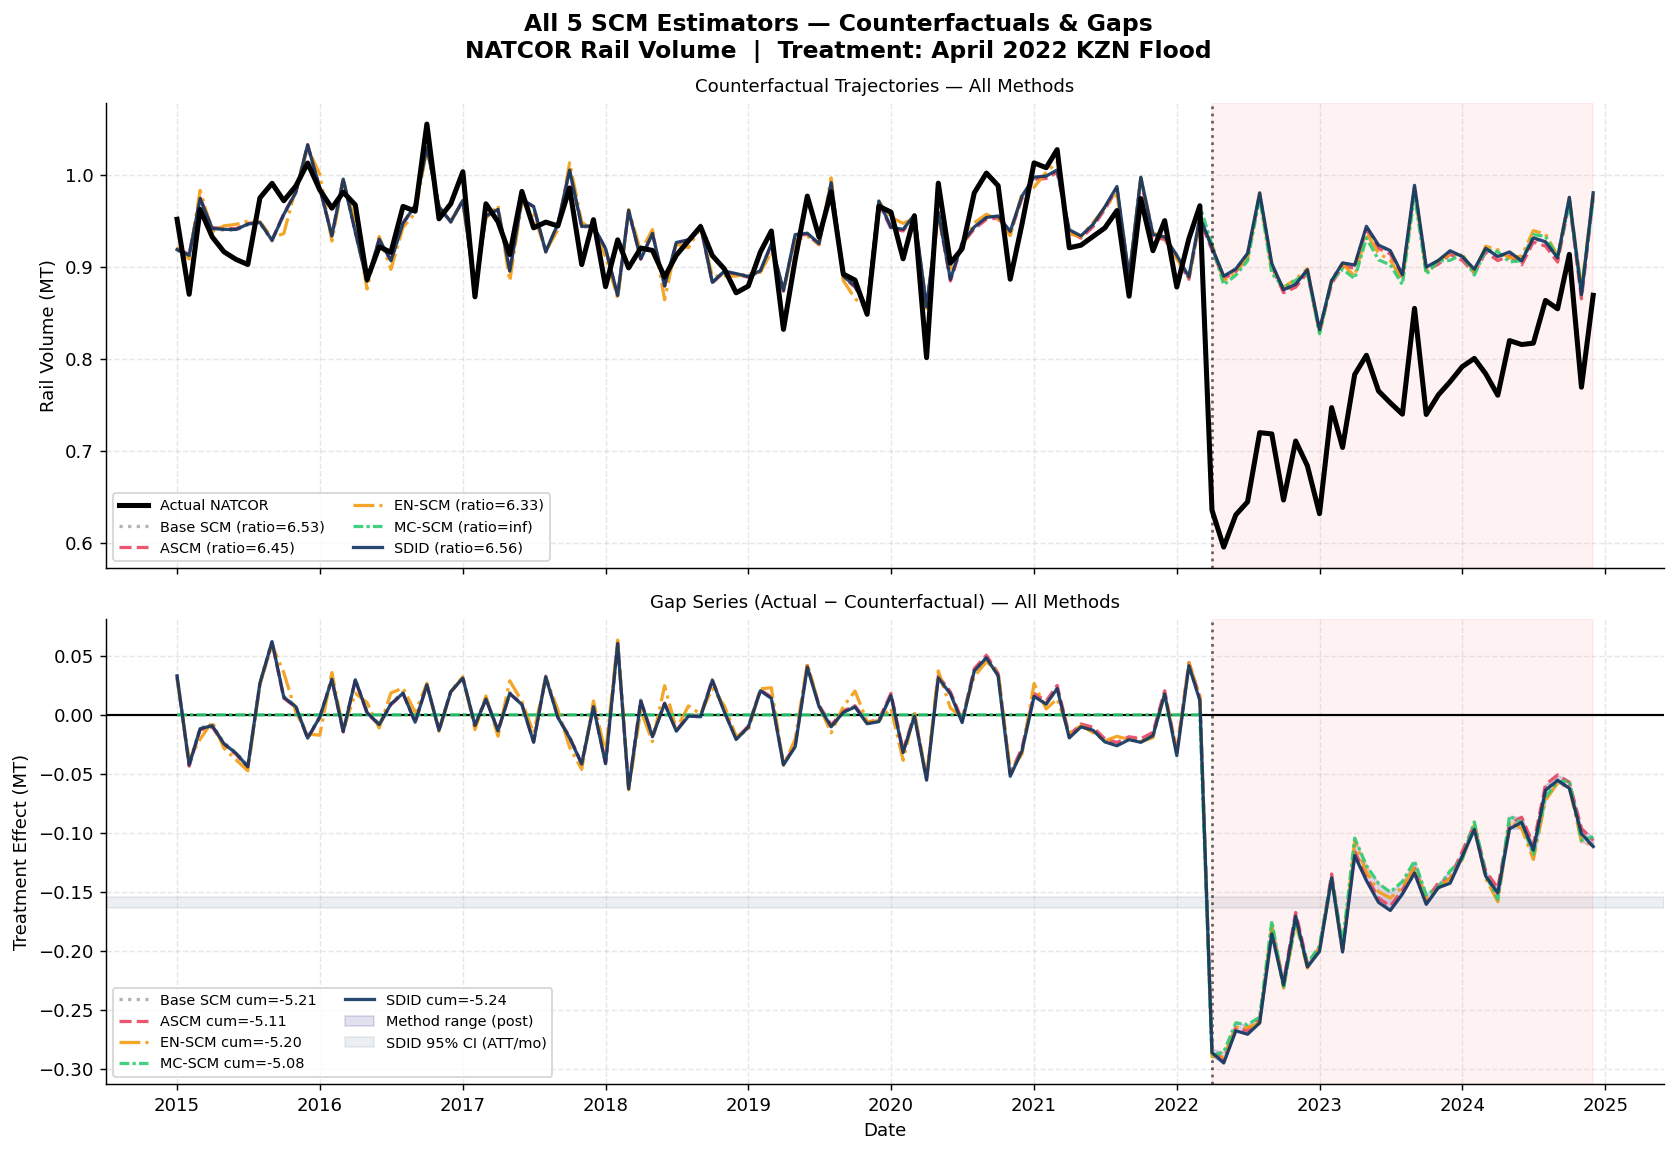

Saved → ../method_A_graph/master_fig1_counterfactuals.png


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 — Figure 1: All Counterfactuals Overlaid
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
fig.suptitle(
    'All 5 SCM Estimators — Counterfactuals & Gaps\n'
    'NATCOR Rail Volume  |  Treatment: April 2022 KZN Flood',
    fontsize=13, fontweight='bold')

# Top: actual + all counterfactuals
ax = axes[0]
ax.plot(t_stamps, Y_all, color='black', lw=2.8, label='Actual NATCOR', zorder=10)
for m in method_order:
    r = results[m]
    ax.plot(t_stamps, r['cf'],
            color=METHOD_COLORS[m], lw=1.8, ls=METHOD_LS[m],
            label=f"{m} (ratio={r['post_r']/r['pre_r']:.2f})", alpha=0.9)
ax.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.6)
ax.axvspan(treat_t, t_stamps[-1], alpha=0.05, color='red')
ax.set_ylabel('Rail Volume (MT)')
ax.legend(fontsize=8, ncol=2)
ax.set_title('Counterfactual Trajectories — All Methods', fontsize=10)

# Bottom: all gaps
ax = axes[1]
ax.axhline(0, color='black', lw=1.2)
ax.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.6)
ax.axvspan(treat_t, t_stamps[-1], alpha=0.05, color='red')
for m in method_order:
    r = results[m]
    ax.plot(t_stamps, r['gap'],
            color=METHOD_COLORS[m], lw=1.8, ls=METHOD_LS[m],
            label=f"{m} cum={r['cum']:.2f}", alpha=0.9)
# Shaded agreement band
gaps_post = np.array([results[m]['gap'][T_pre:] for m in method_order])
ax.fill_between(t_stamps[T_pre:], gaps_post.min(axis=0), gaps_post.max(axis=0),
                alpha=0.12, color='navy', label='Method range (post)')
# SDID CI
if 'jk_se' in results['SDID']:
    ax.axhspan(results['SDID']['ci_lo'], results['SDID']['ci_hi'],
               alpha=0.08, color=METHOD_COLORS['SDID'],
               label=f"SDID 95% CI (ATT/mo)")
ax.set_ylabel('Treatment Effect (MT)')
ax.set_xlabel('Date')
ax.legend(fontsize=8, ncol=2)
ax.set_title('Gap Series (Actual − Counterfactual) — All Methods', fontsize=10)

plt.tight_layout()
save_path = os.path.join(FIG_DIR, 'master_fig1_counterfactuals.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

**What is happening here**  
All five counterfactual trajectories are plotted together on the same axes (top), followed by all five gap series (bottom). The navy shaded band in the gap plot shows the range of disagreement between methods in the post-flood period. A tight band means the methods broadly agree on the shape of the effect. The SDID ATT monthly confidence interval is also shown as a horizontal band for scale reference.

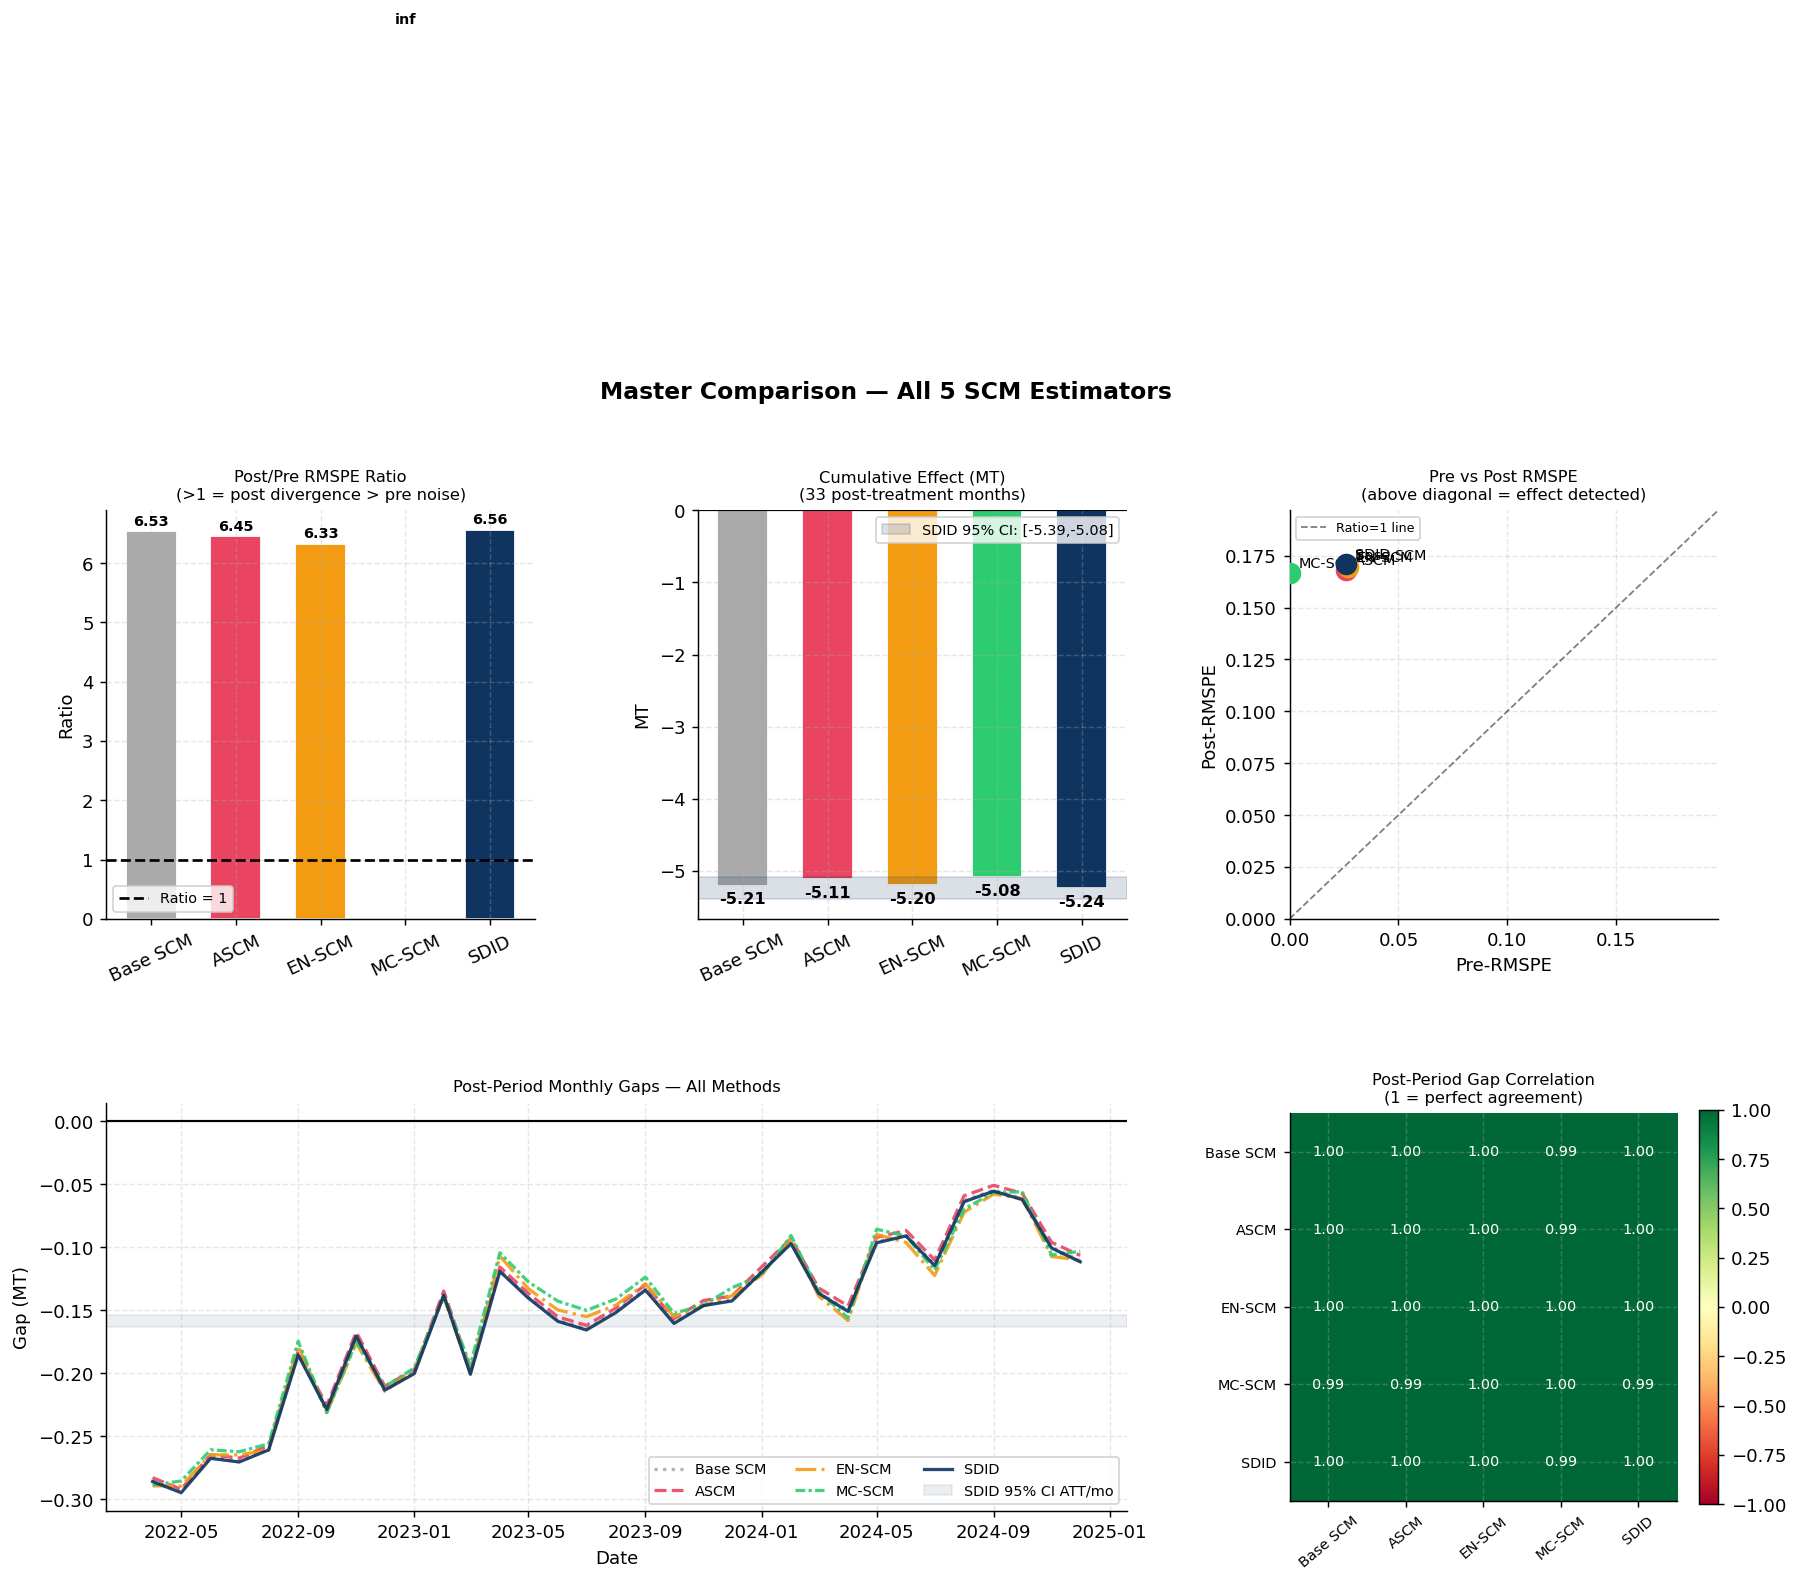

Saved → ../method_A_graph/master_fig2_comparison.png


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 — Figure 2: Metric Comparison Panel
# ═══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.38)

# ── Plot 1: Post/Pre ratio bar ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ratios   = [results[m]['post_r']/results[m]['pre_r'] for m in method_order]
bar_c    = [METHOD_COLORS[m] for m in method_order]
bars     = ax1.bar(method_order, ratios, color=bar_c, edgecolor='white', width=0.6)
ax1.axhline(1.0, color='black', lw=1.5, ls='--', label='Ratio = 1')
for bar, val in zip(bars, ratios):
    ax1.text(bar.get_x() + bar.get_width()/2, min(val, 15) + 0.1,
             f'{val:.2f}', ha='center', fontsize=8, fontweight='bold')
ax1.set_title('Post/Pre RMSPE Ratio\n(>1 = post divergence > pre noise)', fontsize=9)
ax1.set_ylabel('Ratio')
ax1.tick_params(axis='x', rotation=25)
ax1.legend(fontsize=8)

# ── Plot 2: Cumulative effect bar ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
cums  = [results[m]['cum'] for m in method_order]
bars2 = ax2.bar(method_order, cums, color=bar_c, edgecolor='white', width=0.6)
ax2.axhline(0, color='black', lw=1.2)
if 'jk_se' in results['SDID']:
    cl = results['SDID']['ci_lo'] * T_post
    ch = results['SDID']['ci_hi'] * T_post
    ax2.axhspan(cl, ch, alpha=0.15, color=METHOD_COLORS['SDID'],
                label=f'SDID 95% CI: [{cl:.2f},{ch:.2f}]')
    ax2.legend(fontsize=8)
for bar, val in zip(bars2, cums):
    ax2.text(bar.get_x() + bar.get_width()/2,
             val + (0.1 if val >= 0 else -0.25),
             f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_title('Cumulative Effect (MT)\n(33 post-treatment months)', fontsize=9)
ax2.set_ylabel('MT')
ax2.tick_params(axis='x', rotation=25)

# ── Plot 3: Pre vs Post RMSPE scatter ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
pre_rs  = [results[m]['pre_r']  for m in method_order]
post_rs = [results[m]['post_r'] for m in method_order]
for i, m in enumerate(method_order):
    ax3.scatter(pre_rs[i], post_rs[i], color=METHOD_COLORS[m], s=120, zorder=5)
    ax3.annotate(m, (pre_rs[i], post_rs[i]), textcoords='offset points',
                 xytext=(5, 3), fontsize=8)
lim_m = max(max(pre_rs), max(post_rs)) * 1.15
ax3.plot([0, lim_m], [0, lim_m], 'k--', lw=1, alpha=0.5, label='Ratio=1 line')
ax3.set_xlim(0, lim_m); ax3.set_ylim(0, lim_m)
ax3.set_xlabel('Pre-RMSPE'); ax3.set_ylabel('Post-RMSPE')
ax3.set_title('Pre vs Post RMSPE\n(above diagonal = effect detected)', fontsize=9)
ax3.legend(fontsize=7)

# ── Plot 4: Monthly post-period gaps ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
t_post = t_stamps[T_pre:]
for m in method_order:
    ax4.plot(t_post, results[m]['gap'][T_pre:],
             color=METHOD_COLORS[m], lw=1.8, ls=METHOD_LS[m], label=m, alpha=0.9)
ax4.axhline(0, color='black', lw=1.2)
if 'jk_se' in results['SDID']:
    ax4.axhspan(results['SDID']['ci_lo'], results['SDID']['ci_hi'],
                alpha=0.08, color=METHOD_COLORS['SDID'],
                label=f"SDID 95% CI ATT/mo")
ax4.set_title('Post-Period Monthly Gaps — All Methods', fontsize=9)
ax4.set_ylabel('Gap (MT)')
ax4.set_xlabel('Date')
ax4.legend(fontsize=8, ncol=3)

# ── Plot 5: Method agreement heatmap ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
n_m = len(method_order)
agree_mat = np.zeros((n_m, n_m))
for i, m1 in enumerate(method_order):
    for j, m2 in enumerate(method_order):
        g1 = results[m1]['gap'][T_pre:]
        g2 = results[m2]['gap'][T_pre:]
        agree_mat[i, j] = np.corrcoef(g1, g2)[0, 1]
im = ax5.imshow(agree_mat, cmap='RdYlGn', vmin=-1, vmax=1)
ax5.set_xticks(range(n_m)); ax5.set_xticklabels(method_order, rotation=40, fontsize=8)
ax5.set_yticks(range(n_m)); ax5.set_yticklabels(method_order, fontsize=8)
for i in range(n_m):
    for j in range(n_m):
        ax5.text(j, i, f'{agree_mat[i,j]:.2f}', ha='center', va='center', fontsize=8,
                 color='black' if abs(agree_mat[i,j]) < 0.8 else 'white')
plt.colorbar(im, ax=ax5, fraction=0.046)
ax5.set_title('Post-Period Gap Correlation\n(1 = perfect agreement)', fontsize=9)

fig.suptitle('Master Comparison — All 5 SCM Estimators', fontsize=13, fontweight='bold')
save_path = os.path.join(FIG_DIR, 'master_fig2_comparison.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

**What is happening here**  
A five-panel summary figure is produced.

- **Top-left** — Post/pre RMSPE ratio for each method. All bars above 1 means every method detects a post-flood divergence.
- **Top-middle** — Cumulative flood effect for each method, with the SDID 95% CI band shown as a horizontal shaded region.
- **Top-right** — Scatter plot of pre vs post RMSPE. Methods above the diagonal detect an effect; MC-SCM will be near the y-axis due to its perfect pre-period fit by construction.
- **Bottom-left** — Monthly post-flood gaps for all methods, with SDID ATT CI for scale.
- **Bottom-right** — Correlation heatmap of post-period gaps across methods. High correlation (green) means the methods agree on the timing and shape of the effect.

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11 — Final Interpretation & Verdict
# ═══════════════════════════════════════════════════════════════════════════════

print("═" * 80)
print("MASTER COMPARISON — FINAL INTERPRETATION")
print("═" * 80)
print()

ratios_d = {m: results[m]['post_r']/results[m]['pre_r'] for m in method_order}
cums_d   = {m: results[m]['cum'] for m in method_order}

print("1. PRE-PERIOD FIT QUALITY")
best_fit = min(method_order, key=lambda m: results[m]['pre_r'])
worst_fit = max(method_order, key=lambda m: results[m]['pre_r'])
print(f"   Best  pre-RMSPE : {best_fit} ({results[best_fit]['pre_r']:.4f})")
print(f"   Worst pre-RMSPE : {worst_fit} ({results[worst_fit]['pre_r']:.4f})")
print(f"   Note: MC-SCM pre-RMSPE ≈ 0 by construction (observes all pre-period).")
print()

print("2. INFERENCE (Ratio > 1 = post-flood divergence detected)")
for m in method_order:
    flag = '✓' if ratios_d[m] > 1 else '✗'
    print(f"   {flag} {m:<12} ratio = {ratios_d[m]:.4f}")
print()

print("3. EFFECT MAGNITUDE")
for m in method_order:
    extra = ''
    if m == 'SDID':
        cl = results[m]['ci_lo'] * T_post
        ch = results[m]['ci_hi'] * T_post
        extra = f"  [t={results[m]['t_stat']:.2f}, 95% CI cum: {cl:.2f} to {ch:.2f} MT]"
    print(f"   {m:<12}: {cums_d[m]:+.4f} MT cumulative  ({results[m]['avg']:+.4f} MT/month){extra}")
print()

print("4. DIRECTION CONSISTENCY")
signs_d = [np.sign(cums_d[m]) for m in method_order]
n_neg   = sum(1 for s in signs_d if s < 0)
n_pos   = sum(1 for s in signs_d if s > 0)
print(f"   Negative (↓ rail volume): {n_neg}/{len(method_order)} methods")
print(f"   Positive (↑ rail volume): {n_pos}/{len(method_order)} methods")
if n_neg == len(method_order):
    print("   → ALL 5 methods agree: flood reduced NATCOR rail volumes. Strong robustness.")
elif max(n_neg, n_pos) >= 4:
    print(f"   → {max(n_neg, n_pos)}/5 methods agree. Moderate robustness.")
else:
    print("   → Methods disagree on direction. Estimate is fragile.")
print()

print("5. MAGNITUDE RANGE")
cums_list = list(cums_d.values())
excl_base = [cums_d[m] for m in method_order if m != 'Base SCM']
print(f"   All 5 methods: [{min(cums_list):.3f}, {max(cums_list):.3f}] MT")
print(f"   Advanced methods (excl. Base SCM): [{min(excl_base):.3f}, {max(excl_base):.3f}] MT")
print(f"   Inter-method spread: {max(cums_list)-min(cums_list):.3f} MT")
print()

print("6. FORMAL INFERENCE (SDID only)")
t  = results['SDID']['t_stat']
cl = results['SDID']['ci_lo'] * T_post
ch = results['SDID']['ci_hi'] * T_post
print(f"   ATT = {results['SDID']['avg']:+.4f} MT/month  (t = {t:.3f})")
print(f"   Jackknife 95% CI (cumulative): [{cl:.3f}, {ch:.3f}] MT")
print(f"   {'✓ Statistically significant at 95% level' if abs(t) > 1.96 else '✗ Not significant at 95% level'}")
print()
print("═" * 80)
print("OVERALL VERDICT")
print("═" * 80)
if n_neg == len(method_order) and abs(t) > 1.96:
    print("  Strong evidence: all 5 methods agree the KZN flood reduced NATCOR rail volumes.")
    print(f"  Estimated cumulative loss: approximately {np.mean(excl_base):.2f} MT "
          f"(range {min(excl_base):.2f} to {max(excl_base):.2f} MT) over 33 months.")
    print(f"  SDID formal test confirms significance (t={t:.2f}).")
elif n_neg >= 4:
    print("  Moderate evidence: most methods point to a negative flood effect.")
    print("  Interpret with care — not all methods agree.")
else:
    print("  Weak evidence: methods disagree on direction. Do not draw strong conclusions.")

════════════════════════════════════════════════════════════════════════════════
MASTER COMPARISON — FINAL INTERPRETATION
════════════════════════════════════════════════════════════════════════════════

1. PRE-PERIOD FIT QUALITY
   Best  pre-RMSPE : MC-SCM (0.0000)
   Worst pre-RMSPE : EN-SCM (0.0268)
   Note: MC-SCM pre-RMSPE ≈ 0 by construction (observes all pre-period).

2. INFERENCE (Ratio > 1 = post-flood divergence detected)
   ✓ Base SCM     ratio = 6.5350
   ✓ ASCM         ratio = 6.4504
   ✓ EN-SCM       ratio = 6.3267
   ✓ MC-SCM       ratio = inf
   ✓ SDID         ratio = 6.5629

3. EFFECT MAGNITUDE
   Base SCM    : -5.2075 MT cumulative  (-0.1578 MT/month)
   ASCM        : -5.1109 MT cumulative  (-0.1549 MT/month)
   EN-SCM      : -5.1950 MT cumulative  (-0.1574 MT/month)
   MC-SCM      : -5.0834 MT cumulative  (-0.1540 MT/month)
   SDID        : -5.2366 MT cumulative  (-0.1587 MT/month)  [t=-65.61, 95% CI cum: -5.39 to -5.08 MT]

4. DIRECTION CONSISTENCY
   Negative (↓ ra

**What is happening here**  
The final verdict cell summarises results across six dimensions: pre-period fit quality, whether each method detects a post-flood divergence (ratio > 1), the magnitude of the cumulative effect, direction consistency across all five methods, the range of estimates, and the SDID formal inference result.

The overall verdict is printed at the end. If all five methods agree on direction and SDID is statistically significant, this is the strongest possible evidence from this methodological suite that the flood caused a real and lasting reduction in NATCOR rail volumes.